In [1]:
import pandas as pd
import numpy as np


In [4]:
df = pd.read_csv('employees.csv')

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
#size of data
df.shape


(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Subsets
Select specific columns:
df[[col1, col2]]

In [8]:
subset= df[['MonthlyIncome','MonthlyRate']]
subset

,MonthlyIncome,MonthlyRate
0,5993,19479
1,5130,24907
2,2090,2396
3,2909,23159
4,3468,16632
...,...,...
1465,2571,12290
1466,9991,21457
1467,6142,5174
1468,5390,13243


## Aggregation


 - **GroupBy**

 Perform aggregations based on a categorical column:

df[[col1, col2]].groupby(CATEGORICAL).agg({QUANTITATIVE_1: "mean", QUANTITATIVE_2: "max"})

df[[col1, col2]].groupby(CATEGORICAL).mean()

Common aggregation functions:

count, mean, max, min, median, std, and more.

In [ ]:
subdf =df[#subset
    [
        "Age",
        "Department",
        "MonthlyIncome",
        "DistanceFromHome",
        "JobSatisfaction",
        "Education",
        "JobLevel"
    ]
] 

In [8]:
subdf

,Age,Department,MonthlyIncome,DistanceFromHome,JobSatisfaction,Education,JobLevel
0,41,Sales,5993,1,4,2,2
1,49,Research & Development,5130,8,2,1,2
2,37,Research & Development,2090,2,3,2,1
3,33,Research & Development,2909,3,3,4,1
4,27,Research & Development,3468,2,2,1,1
...,...,...,...,...,...,...,...
1465,36,Research & Development,2571,23,4,2,2
1466,39,Research & Development,9991,6,1,1,3
1467,27,Research & Development,6142,4,2,3,2
1468,49,Sales,5390,2,2,3,2


In [9]:
gr = subdf.groupby("Department")


In [10]:
subdf.sample()

,Age,Department,MonthlyIncome,DistanceFromHome,JobSatisfaction,Education,JobLevel
15,29,Research & Development,9980,21,1,4,3


In [11]:
gr.mean()

,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,Education,JobLevel
Department,,,,,,
Human Resources,37.809524,6654.507937,8.698413,2.603175,2.968254,2.031746
Research & Development,37.042664,6281.252862,9.144641,2.726327,2.899063,1.977107
Sales,36.542601,6959.172646,9.365471,2.751121,2.934978,2.255605


In [12]:
gr.MonthlyIncome.max()

Department
Human Resources           19717
Research & Development    19999
Sales                     19847
Name: MonthlyIncome, dtype: int64

In [13]:
double_group = subdf.groupby(["Department", "JobLevel"])


In [14]:
double_group_mean = double_group.mean()

In [15]:
double_group_mean.index

MultiIndex([(       'Human Resources', 1),
            (       'Human Resources', 2),
            (       'Human Resources', 3),
            (       'Human Resources', 4),
            (       'Human Resources', 5),
            ('Research & Development', 1),
            ('Research & Development', 2),
            ('Research & Development', 3),
            ('Research & Development', 4),
            ('Research & Development', 5),
            (                 'Sales', 1),
            (                 'Sales', 2),
            (                 'Sales', 3),
            (                 'Sales', 4),
            (                 'Sales', 5)],
           names=['Department', 'JobLevel'])

In [16]:
subdf.JobLevel.unique()

array([2, 1, 3, 4, 5])

In [17]:
double_group.agg(['min','mean','median','max'])

Age                       MonthlyIncome  \
                                min       mean median max           min   
Department             JobLevel                                           
Human Resources        1         19  33.454545   33.0  59          1555   
                       2         30  38.538462   39.0  46          3886   
                       3         29  40.166667   39.5  54          7988   
                       4         40  46.750000   46.5  54         14026   
                       5         41  49.857143   50.0  59         18200   
Research & Development 1         18  33.000000   32.0  59          1009   
                       2         22  37.277580   36.0  58          2042   
                       3         27  40.565891   39.0  60          5210   
                       4         29  47.573529   49.0  59         11103   
                       5         39  47.612245   48.0  60         18061   
Sales                  1         18  29.407895   29.0  52          1052   
                       2         24  35.700000   34.0  60          2086   
                       3         27  39.337349   37.0  60          7082   
                       4         33  47.558824   46.0  58         11836   
                       5         40  47.153846   46.0  55         18041   

                                                               \
                                         mean   median    max   
Department             JobLevel                                 
Human Resources        1          2733.212121   2696.0   4936   
                       2          5563.461538   5985.0   6430   
                       3          9623.000000   9853.0  10725   
                       4         16147.500000  16618.0  17328   
                       5         19197.857143  19189.0  19717   
Research & Development 1          2840.064516   2693.0   4968   
                       2          5291.238434   5228.0   9957   
                       3         10170.488372  10312.0  13757   
                       4         15634.676471  16370.5  17924   
                       5         19218.510204  19237.0  19999   
Sales                  1          2506.723684   2553.0   4400   
                       2          5746.054167   5423.0   9998   
                       3          9282.289157   9250.0  13591   
                       4         15166.264706  15699.5  17875   
                       5         19088.000000  19068.0  19847   

                                DistanceFromHome                        \
                                             min       mean median max   
Department             JobLevel                                          
Human Resources        1                       1   8.333333    6.0  25   
                       2                       1   4.615385    3.0  11   
                       3                       1  15.000000   18.0  26   
                       4                       5  11.750000    8.0  26   
                       5                       1  10.857143    8.0  26   
Research & Development 1                       1   8.610599    6.0  29   
                       2                       1  10.170819    8.0  29   
                       3                       1   9.658915    7.0  29   
                       4                       1   9.676471    6.0  29   
                       5                       1   5.897959    4.0  25   
Sales                  1                       1   8.881579    7.0  29   
                       2                       1   9.387500    7.5  29   
                       3                       1   9.566265    8.0  29   
                       4                       1  11.147059    8.5  29   
                       5                       1   5.846154    4.0  26   

                                JobSatisfaction                       \
                                            min      mean median max   
Department             JobLevel  

In [18]:
double_group.agg(['min','mean','median','max']).columns

MultiIndex([(             'Age',    'min'),
            (             'Age',   'mean'),
            (             'Age', 'median'),
            (             'Age',    'max'),
            (   'MonthlyIncome',    'min'),
            (   'MonthlyIncome',   'mean'),
            (   'MonthlyIncome', 'median'),
            (   'MonthlyIncome',    'max'),
            ('DistanceFromHome',    'min'),
            ('DistanceFromHome',   'mean'),
            ('DistanceFromHome', 'median'),
            ('DistanceFromHome',    'max'),
            ( 'JobSatisfaction',    'min'),
            ( 'JobSatisfaction',   'mean'),
            ( 'JobSatisfaction', 'median'),
            ( 'JobSatisfaction',    'max'),
            (       'Education',    'min'),
            (       'Education',   'mean'),
            (       'Education', 'median'),
            (       'Education',    'max')],
           )

- **Pivot Table**



Create pivot tables to summarize data:

df.pivot_table(values="MonthlyIncome", index="Department", aggfunc="mean")

Pivot tables offer a concise way to aggregate and compare data.



In [19]:
pd.pivot_table(
    df,#which table
    index="Department",
    columns="JobLevel",
    values="MonthlyIncome",
    aggfunc="min"
)

JobLevel,1,2,3,4,5
Department,,,,,
Human Resources,1555,3886,7988,14026,18200
Research & Development,1009,2042,5210,11103,18061
Sales,1052,2086,7082,11836,18041


In [20]:
gr.mean()

,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,Education,JobLevel
Department,,,,,,
Human Resources,37.809524,6654.507937,8.698413,2.603175,2.968254,2.031746
Research & Development,37.042664,6281.252862,9.144641,2.726327,2.899063,1.977107
Sales,36.542601,6959.172646,9.365471,2.751121,2.934978,2.255605


- **crosstab**

Compute cross-tabulations to analyze the relationship between two categorical variables:

- Default behavior counts occurrences.
- Use aggfunc="mean" for aggregating quantitative variables.
- Ensure you select appropriate variables.


In [21]:
subdf =df[
    [
        "Age",
        "Department",
        "MonthlyIncome",
        "DistanceFromHome",
        "JobSatisfaction",
        "Education",
        "JobLevel",
        "EducationField"
    ]
] 

In [22]:
pd.crosstab(subdf.Department, subdf.EducationField)


EducationField,Human Resources,Life Sciences,Marketing,Medical,Other,Technical Degree
Department,,,,,,
Human Resources,27,16,0,13,3,4
Research & Development,0,440,0,363,64,94
Sales,0,150,159,88,15,34


In [23]:
pd.crosstab(
    subdf.Department,
    subdf.EducationField,
    subdf.MonthlyIncome,
    aggfunc='mean'
   )


EducationField,Human Resources,Life Sciences,Marketing,Medical,Other,Technical Degree
Department,,,,,,
Human Resources,7241.148148,6914.062500,NaN,6594.076923,5016.666667,3081.250000
Research & Development,NaN,6179.984091,NaN,6539.223140,6278.687500,5760.819149
Sales,NaN,7246.233333,7348.584906,6377.227273,5398.733333,6066.294118


In [24]:
pd.pivot_table(
    df,
    index='Department',
    columns='EducationField',
    values='MonthlyIncome',
    aggfunc='mean'
)

EducationField,Human Resources,Life Sciences,Marketing,Medical,Other,Technical Degree
Department,,,,,,
Human Resources,7241.148148,6914.062500,NaN,6594.076923,5016.666667,3081.250000
Research & Development,NaN,6179.984091,NaN,6539.223140,6278.687500,5760.819149
Sales,NaN,7246.233333,7348.584906,6377.227273,5398.733333,6066.294118


## Visualization

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Monthly Income')

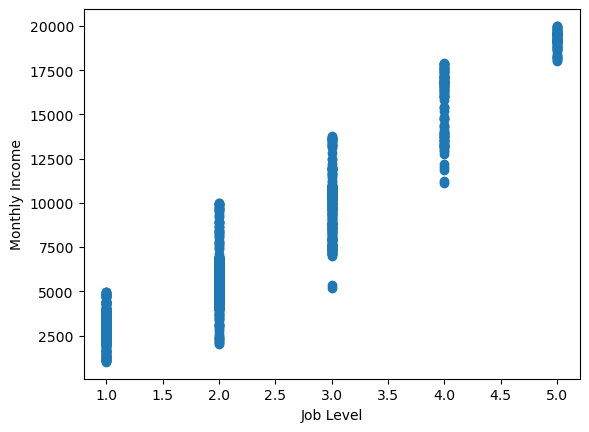

In [26]:
plt.scatter(
    x=df.JobLevel,
    y=df.MonthlyIncome
    )
plt.xlabel("Job Level")
plt.ylabel("Monthly Income")

<Axes: xlabel='JobLevel', ylabel='MonthlyIncome'>

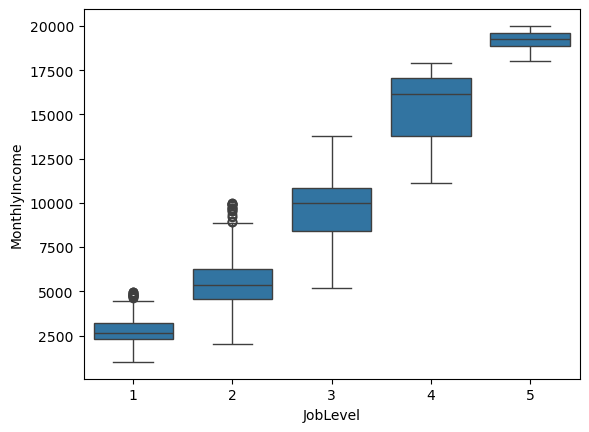

In [27]:
sns.boxplot(
    data=df,
    x='JobLevel',
    y='MonthlyIncome'
)

/opt/anaconda3/envs/cs224n/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 81.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/cs224n/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 71.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/cs224n/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 36.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/cs224n/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/cs224n/lib/python3.12/site-packa

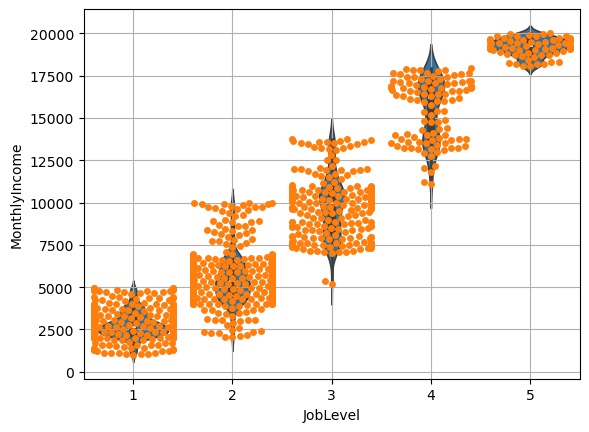

In [28]:
sns.violinplot(
    data=df,
    x='JobLevel'
    ,y='MonthlyIncome'
    )
sns.swarmplot(
    data=df,
    x='JobLevel'
    ,y='MonthlyIncome'
)
plt.grid()

## JOINS & MERGE & CONCAT

**Concatenation**
- Combining DataFrames physically (not relationally):

      - Side by side: concat on axis=1.

          - Use when DataFrames don't share columns or have a common key.

      - Top & bottom: concat on axis=0 (appending rows).
      
          - Suitable when DataFrames share columns.

In [29]:
df_sales = df[
    df.Department == 'Sales'
]
df_rnd = df[
    df.Department == 'Research & Development'
]

In [30]:
(df.Department == 'Sales').mean()

0.3034013605442177

In [31]:
(df.Department == 'Research & Development').mean()

0.6537414965986394

In [33]:
pd.concat(
    [df_rnd, df_sales],
    keys=['Sales', 'Research & Development']
)

Age Attrition     BusinessTravel  DailyRate  \
Sales                  1      49        No  Travel_Frequently        279   
                       2      37       Yes      Travel_Rarely       1373   
                       3      33        No  Travel_Frequently       1392   
                       4      27        No      Travel_Rarely        591   
                       5      32        No  Travel_Frequently       1005   
...                          ...       ...                ...        ...   
Research & Development 1454   45        No      Travel_Rarely        374   
                       1461   50       Yes      Travel_Rarely        410   
                       1462   39        No      Travel_Rarely        722   
                       1464   26        No      Travel_Rarely       1167   
                       1468   49        No  Travel_Frequently       1023   

                                         Department  DistanceFromHome  \
Sales                  1     Research & Development                 8   
                       2     Research & Development                 2   
                       3     Research & Development                 3   
                       4     Research & Development                 2   
                       5     Research & Development                 2   
...                                             ...               ...   
Research & Development 1454                   Sales                20   
                       1461                   Sales                28   
                       1462                   Sales                24   
                       1464                   Sales                 5   
                       1468                   Sales                 2   

                             Education EducationField  EmployeeCount  \
Sales                  1             1  Life Sciences              1   
                       2             2          Other              1   
                       3             4  Life Sciences              1   
                       4             1        Medical              1   
                       5             2  Life Sciences              1   
...                                ...            ...            ...   
Research & Development 1454          3  Life Sciences              1   
                       1461          3      Marketing              1   
                       1462          1      Marketing              1   
                       1464          3          Other              1   
                       1468          3        Medical              1   

                             EmployeeNumber  ...  RelationshipSatisfaction  \
Sales                  1                  2  ...                         4   
                       2                  4  ...                         2   
                       3                  5  ...                         3   
                       4                  7  ...                         4   
                       5                  8  ...                         3   
...                                     ...  ...                       ...   
Research & Development 1454            2046  ...                         3   
                       1461            2055  ...                         2   
                       1462            2056  ...                         1   
                       1464            2060  ...                         4   
                       1468            2065  ...                         4   

                            StandardHours  StockOptionLevel  \
Sales                  1               80                 1   
                       2               80                 0   
                       3               80                 0   
                       4               80                 1   
                       5               80                 0   
...                                   ...               ...

In [34]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [40]:
basic_info = df[[
    'EmployeeNumber','MonthlyIncome','JobLevel','JobRole', 
]]
extra_info =df[[
    'EmployeeNumber','BusinessTravel','JobSatisfaction','MaritalStatus','WorkLifeBalance'
]].set_index(['EmployeeNumber'])

In [41]:
basic_info.shape, extra_info.shape

((1470, 4), (1470, 4))

In [42]:
basic_info.head()

,EmployeeNumber,MonthlyIncome,JobLevel,JobRole
0,1,5993,2,Sales Executive
1,2,5130,2,Research Scientist
2,4,2090,1,Laboratory Technician
3,5,2909,1,Research Scientist
4,7,3468,1,Laboratory Technician


In [43]:
extra_info.head()

,BusinessTravel,JobSatisfaction,MaritalStatus,WorkLifeBalance
EmployeeNumber,,,,
1,Travel_Rarely,4,Single,1
2,Travel_Frequently,2,Married,3
4,Travel_Rarely,3,Single,3
5,Travel_Frequently,3,Married,3
7,Travel_Rarely,2,Married,3


In [37]:
pd.concat(
    [basic_info, extra_info], axis=1
)

,EmployeeNumber,MonthlyIncome,JobLevel,JobRole,EmployeeNumber,BusinessTravel,JobSatisfaction,MaritalStatus,WorkLifeBalance
0,1,5993,2,Sales Executive,1,Travel_Rarely,4,Single,1
1,2,5130,2,Research Scientist,2,Travel_Frequently,2,Married,3
2,4,2090,1,Laboratory Technician,4,Travel_Rarely,3,Single,3
3,5,2909,1,Research Scientist,5,Travel_Frequently,3,Married,3
4,7,3468,1,Laboratory Technician,7,Travel_Rarely,2,Married,3
...,...,...,...,...,...,...,...,...,...
1465,2061,2571,2,Laboratory Technician,2061,Travel_Frequently,4,Married,3
1466,2062,9991,3,Healthcare Representative,2062,Travel_Rarely,1,Married,3
1467,2064,6142,2,Manufacturing Director,2064,Travel_Rarely,2,Married,3
1468,2065,5390,2,Sales Executive,2065,Travel_Frequently,2,Married,2


### watch for index when you ues ' concat'

## Merge & Join (Pandas)
- Merge: Combining DataFrames based on common columns.
- Join: Combining DataFrames based on common indices.
- In SQL, join operations are performed on columns.




- left_df: The left DataFrame you want to merge.
- right_df: The right DataFrame you want to merge.
- on: The column(s) on which you want to perform the merge. These columns should exist in both DataFrames and serve as the key(s) for the merge operation.
- how: The type of join you want to perform (e.g., 'inner', 'outer', 'left', 'right').

## Merge

In [44]:
basic_info = df[[
    'EmployeeNumber','MonthlyIncome','JobLevel','JobRole', 
]]
extra_info =df[[
    'EmployeeNumber','BusinessTravel','JobSatisfaction','MaritalStatus','WorkLifeBalance'
]]

In [45]:
basic_info.merge(extra_info) #gets the same columns 

,EmployeeNumber,MonthlyIncome,JobLevel,JobRole,BusinessTravel,JobSatisfaction,MaritalStatus,WorkLifeBalance
0,1,5993,2,Sales Executive,Travel_Rarely,4,Single,1
1,2,5130,2,Research Scientist,Travel_Frequently,2,Married,3
2,4,2090,1,Laboratory Technician,Travel_Rarely,3,Single,3
3,5,2909,1,Research Scientist,Travel_Frequently,3,Married,3
4,7,3468,1,Laboratory Technician,Travel_Rarely,2,Married,3
...,...,...,...,...,...,...,...,...
1465,2061,2571,2,Laboratory Technician,Travel_Frequently,4,Married,3
1466,2062,9991,3,Healthcare Representative,Travel_Rarely,1,Married,3
1467,2064,6142,2,Manufacturing Director,Travel_Rarely,2,Married,3
1468,2065,5390,2,Sales Executive,Travel_Frequently,2,Married,2


In [46]:
df1 = pd.DataFrame(

    {

        "employee_id": ["E0", "E0", "E2", "E3"],

        "department": ["D0", "D1", "D2", "D1"],

        "salary": ["S0", "S1", "S2", "S3"],

        "bonus": ["B0", "B1", "B2", "B3"],

    }

)

 

df2 = pd.DataFrame(

    {

        "employee_id": ["E0", "E1", "E2", "E3"],

        "department": ["D0", "D0", "D1", "D1"],

        "JobRole": ["JR0", "JR1", "JR2", "JR3"],

        "JobLevel": ["JL0", "JL1", "JL2", "JL3"],

    }

)

 

df3 = pd.DataFrame(

    {

        "employee_id": ["E90", "E1", "E2", "E3"],

        "department": ["D0", "D1", "D2", "D2"],

        "EducationField": ["EF0", "EF1", "EF2", "EF3"],

        "EnvironmentSatisfaction": ["ES0", "ES1", "ES2", "ES3"],

    }

)


In [47]:
from IPython.display import display_html

df1_styler = df1.style.set_table_attributes("style='display=inline'").set_caption('Left table')
df2_styler = df2.style.set_table_attributes("style='display=inline'").set_caption('Right table')
display_html(df1_styler._repr_html_()+" "+df2_styler._repr_html_(), raw=True)

,employee_id,department,salary,bonus
0,E0,D0,S0,B0
1,E0,D1,S1,B1
2,E2,D2,S2,B2
3,E3,D1,S3,B3
,employee_id,department,JobRole,JobLevel
0,E0,D0,JR0,JL0
1,E1,D0,JR1,JL1
2,E2,D1,JR2,JL2
3,E3,D1,JR3,JL3


In [49]:
df1.merge(
    df2,
    on='employee_id',
    how='inner'
)

,employee_id,department_x,salary,bonus,department_y,JobRole,JobLevel
0,E0,D0,S0,B0,D0,JR0,JL0
1,E0,D1,S1,B1,D0,JR0,JL0
2,E2,D2,S2,B2,D1,JR2,JL2
3,E3,D1,S3,B3,D1,JR3,JL3


In [ ]:
df1.merge(
    df2,
    how='right'
)

,employee_id,department,salary,bonus,JobRole,JobLevel
0,E0,D0,S0,B0,JR0,JL0
1,E1,D0,NaN,NaN,JR1,JL1
2,E2,D1,NaN,NaN,JR2,JL2
3,E3,D1,S3,B3,JR3,JL3


In [54]:
df1.merge(
    df2,
    how='left'
)

,employee_id,department,salary,bonus,JobRole,JobLevel
0,E0,D0,S0,B0,JR0,JL0
1,E0,D1,S1,B1,NaN,NaN
2,E2,D2,S2,B2,NaN,NaN
3,E3,D1,S3,B3,JR3,JL3


In [ ]:
df1.merge(
    df2,
    how='outer' #keeping all keys from both table
)

,employee_id,department,salary,bonus,JobRole,JobLevel
0,E0,D0,S0,B0,JR0,JL0
1,E0,D1,S1,B1,NaN,NaN
2,E1,D0,NaN,NaN,JR1,JL1
3,E2,D1,NaN,NaN,JR2,JL2
4,E2,D2,S2,B2,NaN,NaN
5,E3,D1,S3,B3,JR3,JL3


In [60]:
df1.merge(
    df2,
    how='inner' #keeping  keys in  both table
)

,employee_id,department,salary,bonus,JobRole,JobLevel
0,E0,D0,S0,B0,JR0,JL0
1,E3,D1,S3,B3,JR3,JL3


In [61]:
df1.merge(df2,how='inner').shape ,df1.merge(df2,how='outer').shape

((2, 6), (6, 6))

In [62]:
df1.merge(
    df2,
    how='cross'
)

,employee_id_x,department_x,salary,bonus,employee_id_y,department_y,JobRole,JobLevel
0,E0,D0,S0,B0,E0,D0,JR0,JL0
1,E0,D0,S0,B0,E1,D0,JR1,JL1
2,E0,D0,S0,B0,E2,D1,JR2,JL2
3,E0,D0,S0,B0,E3,D1,JR3,JL3
4,E0,D1,S1,B1,E0,D0,JR0,JL0
5,E0,D1,S1,B1,E1,D0,JR1,JL1
6,E0,D1,S1,B1,E2,D1,JR2,JL2
7,E0,D1,S1,B1,E3,D1,JR3,JL3
8,E2,D2,S2,B2,E0,D0,JR0,JL0
9,E2,D2,S2,B2,E1,D0,JR1,JL1


In [66]:
df1.drop('department', axis=1).merge(df1, how='cross')

,employee_id_x,salary_x,bonus_x,employee_id_y,department,salary_y,bonus_y
0,E0,S0,B0,E0,D0,S0,B0
1,E0,S0,B0,E0,D1,S1,B1
2,E0,S0,B0,E2,D2,S2,B2
3,E0,S0,B0,E3,D1,S3,B3
4,E0,S1,B1,E0,D0,S0,B0
5,E0,S1,B1,E0,D1,S1,B1
6,E0,S1,B1,E2,D2,S2,B2
7,E0,S1,B1,E3,D1,S3,B3
8,E2,S2,B2,E0,D0,S0,B0
9,E2,S2,B2,E0,D1,S1,B1


## join

In [68]:
df1 = pd.DataFrame(

    {

        "employee_id": ["E0", "E0", "E2", "E3"],

        "department": ["D0", "D1", "D2", "D1"],

        "salary": ["S0", "S1", "S2", "S3"],

        "bonus": ["B0", "B1", "B2", "B3"],

    }

).set_index('employee_id')
df1.index.rename('id',inplace=True)

 

df2 = pd.DataFrame(

    {

        "employee_id": ["E0", "E1", "E2", "E3"],

        "department": ["D0", "D0", "D1", "D1"],

        "JobRole": ["JR0", "JR1", "JR2", "JR3"],

        "JobLevel": ["JL0", "JL1", "JL2", "JL3"],

    }

).set_index('employee_id')
df2.index.rename('id',inplace=True)

 

df3 = pd.DataFrame(

    {

        "employee_id": ["E90", "E1", "E2", "E3"],

        "department": ["D0", "D1", "D2", "D2"],

        "EducationField": ["EF0", "EF1", "EF2", "EF3"],

        "EnvironmentSatisfaction": ["ES0", "ES1", "ES2", "ES3"],

    }

)

from IPython.display import display_html

df1_styler = df1.style.set_table_attributes("style='display=inline'").set_caption('Left table')
df2_styler = df2.style.set_table_attributes("style='display=inline'").set_caption('Right table')
display_html(df1_styler._repr_html_()+" "+df2_styler._repr_html_(), raw=True)

,department,salary,bonus
id,,,
E0,D0,S0,B0
E0,D1,S1,B1
E2,D2,S2,B2
E3,D1,S3,B3
,department,JobRole,JobLevel
id,,,
E0,D0,JR0,JL0
E1,D0,JR1,JL1
E2,D1,JR2,JL2
